# 01 — EDA de Efectos Secundarios por Componentes

Este notebook realiza la exploración específica de las columnas `Composition` y `Side_effects`
**antes de limpiar**, con el objetivo de entender su estructura, detectar
anomalías y justificar las decisiones de limpieza implementadas en `cleaning.py`.

In [8]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from src.load_data import load_medicine_data
from src.enfoque_03_efectos_secundarios_componentes.cleaning import (
    extraer_componentes,
    extraer_efectos_secundarios,
)

df = load_medicine_data(download_if_missing=False)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 11,825 filas × 9 columnas


## 1. Estructura general del dataset

Antes de extraer componentes y efectos, inspeccionamos los tipos
de datos y las primeras filas para entender con qué trabajaremos.

In [9]:
# Tipos de datos
print("=== TIPOS DE COLUMNAS ===")
print(df.dtypes)

=== TIPOS DE COLUMNAS ===
Medicine Name           str
Composition             str
Uses                    str
Side_effects            str
Image URL               str
Manufacturer            str
Excellent Review %    int64
Average Review %      int64
Poor Review %         int64
dtype: object


In [10]:
# Primeras filas de Composition y Side_effects (nuestras columnas clave)
df[["Medicine Name", "Composition", "Side_effects"]].head(3)

,Medicine Name,Composition,Side_effects
0,Avastin 400mg Injection,Bevacizumab (400mg),Rectal bleeding Taste change Headache Noseblee...
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Vomiting Nausea Diarrhea Mucocutaneous candidi...
2,Azithral 500 Tablet,Azithromycin (500mg),Nausea Abdominal pain Diarrhea


## 2. Distribución por número de componentes (datos raw)

Contamos cuántos componentes tiene cada medicamento **antes de cualquier limpieza**,
usando `extraer_componentes` de forma exploratoria.

In [11]:
# Distribución de n_components en datos raw
df["n_components_preview"] = df["Composition"].apply(
    lambda x: len(extraer_componentes(x))
)

dist = df["n_components_preview"].value_counts().sort_index()
dist_pct = (dist / len(df) * 100).round(2)

resumen = pd.DataFrame({
    "Medicamentos": dist,
    "Porcentaje (%)": dist_pct
})
resumen.index.name = "n_componentes"
resumen

,Medicamentos,Porcentaje (%)
n_componentes,,
1,7069,59.78
2,3596,30.41
3,933,7.89
4,150,1.27
5,51,0.43
6,16,0.14
7,7,0.06
8,2,0.02
9,1,0.01


## 3. Distribución por número de efectos secundarios (datos raw)

Contamos cuántos efectos secundarios tiene cada medicamento usando `extraer_efectos_secundarios`.
Esta es la columna central del Enfoque 3.

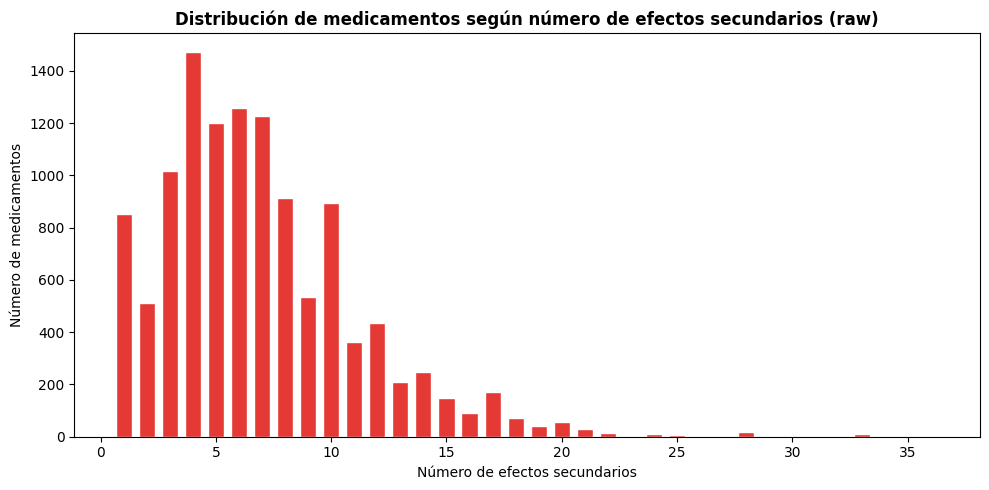

count    11825.00
mean         6.92
std          4.30
min          1.00
25%          4.00
50%          6.00
75%          9.00
max         36.00
Name: n_efectos_preview, dtype: float64


In [12]:
# Distribución de n_efectos en datos raw
df["n_efectos_preview"] = df["Side_effects"].apply(
    lambda x: len(extraer_efectos_secundarios(x))
)

dist_ef = df["n_efectos_preview"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dist_ef.index, dist_ef.values, color="#E53935", edgecolor="white", width=0.7)
ax.set_xlabel("Número de efectos secundarios")
ax.set_ylabel("Número de medicamentos")
ax.set_title("Distribución de medicamentos según número de efectos secundarios (raw)", fontweight="bold")
plt.tight_layout()
plt.show()

print(df["n_efectos_preview"].describe().round(2))

## 4. Detección de duplicados completos

Identificamos registros donde todas las columnas son idénticas.
Estos serán eliminados en el pipeline de limpieza.

In [13]:
duplicados = df.duplicated().sum()
print(f"Duplicados completos detectados: {duplicados}")
print(f"Porcentaje sobre el total: {duplicados / len(df) * 100:.2f}%")

# Ver ejemplos de duplicados
df[df.duplicated(keep=False)].sort_values("Composition").head(6)

Duplicados completos detectados: 84
Porcentaje sobre el total: 0.71%


,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %,n_components_preview,n_efectos_preview
2305,Excex Gel,Adapalene (0.1% w/w) + Clindamycin (1% w/w),Treatment of Acne,Skin peeling Erythema skin redness Itching Dry...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Zee Laboratories,51,41,8,2,5
2304,Excex Gel,Adapalene (0.1% w/w) + Clindamycin (1% w/w),Treatment of Acne,Skin peeling Erythema skin redness Itching Dry...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Zee Laboratories,51,41,8,2,5
6233,Noworm Chewable Tablet,Albendazole (400mg),Treatment of Parasitic infections,Vomiting Dizziness Increased liver enzymes Nau...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alkem Laboratories Ltd,40,34,26,1,5
6209,Noworm Chewable Tablet,Albendazole (400mg),Treatment of Parasitic infections,Vomiting Dizziness Increased liver enzymes Nau...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alkem Laboratories Ltd,40,34,26,1,5
11406,Xrate Cough Expectorant Sugar Free,Ambroxol (15mg/5ml) + Guaifenesin (50mg/5ml) +...,Cough,Nausea Diarrhea Vomiting Dizziness Headache Ra...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Celsius Healthcare Pvt Ltd,67,33,0,4,15
11405,Xrate Cough Expectorant Sugar Free,Ambroxol (15mg/5ml) + Guaifenesin (50mg/5ml) +...,Cough,Nausea Diarrhea Vomiting Dizziness Headache Ra...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Celsius Healthcare Pvt Ltd,67,33,0,4,15


## 5. Vista previa del problema estructural de Side_effects

Los efectos secundarios están concatenados **sin separador explícito**,
usando la mayúscula inicial de cada palabra como separador implícito.

Este es el desafío técnico principal del Enfoque 3:
separar los efectos usando expresiones regulares.

In [14]:
# Ejemplos del problema estructural en Side_effects
ejemplos = df[["Medicine Name", "Composition", "Side_effects"]].head(4)
for _, row in ejemplos.iterrows():
    print(f"   Medicamento        : {row['Medicine Name']}")
    print(f"   Composición        : {row['Composition']}")
    print(f"   Efectos secundarios: {row['Side_effects']}")
    print(f"   Efectos parseados  : {extraer_efectos_secundarios(row['Side_effects'])}")
    print()

   Medicamento        : Avastin 400mg Injection
   Composición        : Bevacizumab (400mg)
   Efectos secundarios: Rectal bleeding Taste change Headache Nosebleeds Back pain Dry skin High blood pressure Protein in urine Inflammation of the nose
   Efectos parseados  : ['rectal bleeding', 'taste change', 'headache', 'nosebleeds', 'back pain', 'dry skin', 'high blood pressure', 'protein in urine', 'inflammation of the nose']

   Medicamento        : Augmentin 625 Duo Tablet
   Composición        : Amoxycillin  (500mg) +  Clavulanic Acid (125mg)
   Efectos secundarios: Vomiting Nausea Diarrhea Mucocutaneous candidiasis
   Efectos parseados  : ['vomiting', 'nausea', 'diarrhea', 'mucocutaneous candidiasis']

   Medicamento        : Azithral 500 Tablet
   Composición        : Azithromycin (500mg)
   Efectos secundarios: Nausea Abdominal pain Diarrhea
   Efectos parseados  : ['nausea', 'abdominal pain', 'diarrhea']

   Medicamento        : Ascoril LS Syrup
   Composición        : Ambroxol (3

## 6. Conclusiones del EDA

A partir de este análisis se tomaron las siguientes decisiones de limpieza,
implementadas en `cleaning.py`:

1. **Eliminar 84 duplicados completos** — no aportan información nueva.
2. **Normalizar espacios en `Composition`** — garantiza parseo confiable del separador `+`.
3. **Extraer componentes sin dosis** — las dosis no son relevantes para analizar efectos.
4. **Parsear `Side_effects` con regex** — separar efectos con mayúscula inicial como delimitador.
5. **Marcar anomalías sin eliminar** — columnas `anomalia_componentes` y `anomalia_efectos`.

➡️ El siguiente notebook ejecuta la limpieza y transformación completa.